In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pickle 

import nltk  
import re
from nltk.corpus import stopwords  
from nltk.tokenize import word_tokenize  
from nltk.stem import PorterStemmer, WordNetLemmatizer 
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA  

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

Loading Datasets

In [2]:
df1 = pd.read_csv("../data/Audible_Catlog.csv")
df2 = pd.read_csv("../data/Audible_Catlog_Advanced_Features.csv")

In [3]:
df1.shape

(6368, 5)

In [5]:
df2.shape

(4464, 8)

In [6]:
df = pd.merge(df1, df2, on=["Book Name","Author"], how="inner",  suffixes=('', '_df2'))
df

,Book Name,Author,Rating,Number of Reviews,Price,Rating_df2,Number of Reviews_df2,Price_df2,Description,Listening Time,Ranks and Genre
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0,4.9,371.0,10080,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top..."
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0,4.6,3682.0,615,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top..."
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0,4.4,20306.0,10378,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top..."
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0,4.6,4678.0,888,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top..."
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0,4.6,4308.0,1005,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top..."
...,...,...,...,...,...,...,...,...,...,...,...
4246,The Prophet & The Wanderer,Khalil Gibran,4.1,6.0,539.0,4.1,6.0,539,"Sorry, we just need to make sure you're not a ...",-1,-1
4247,Make Today Count: The Secret of Your Success I...,John C. Maxwell,4.7,301.0,500.0,4.7,307.0,500,"Sorry, we just need to make sure you're not a ...",-1,-1
4248,Make Today Count: The Secret of Your Success I...,John C. Maxwell,4.7,301.0,500.0,4.7,307.0,500,"Sorry, we just need to make sure you're not a ...",-1,-1
4249,वॉयर - एक कामुक लघुकथा,सेसिलि रोसडैल,-1.0,NaN,65.0,-1.0,NaN,65,"Sorry, we just need to make sure you're not a ...",-1,-1


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4251 entries, 0 to 4250
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Book Name              4251 non-null   object 
 1   Author                 4251 non-null   object 
 2   Rating                 4251 non-null   float64
 3   Number of Reviews      3838 non-null   float64
 4   Price                  4249 non-null   float64
 5   Rating_df2             4251 non-null   float64
 6   Number of Reviews_df2  3839 non-null   float64
 7   Price_df2              4251 non-null   int64  
 8   Description            4245 non-null   object 
 9   Listening Time         4251 non-null   object 
 10  Ranks and Genre        4251 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 365.4+ KB


In [8]:
df.columns


Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price',
       'Rating_df2', 'Number of Reviews_df2', 'Price_df2', 'Description',
       'Listening Time', 'Ranks and Genre'],
      dtype='object')

In [9]:
df.duplicated(subset=['Book Name', 'Author']).sum()
duplicates = df[df.duplicated(subset=['Book Name', 'Author'], keep=False)]
print(duplicates)

                                              Book Name             Author  \
6                                               Sapiens  Yuval Noah Harari   
7                                               Sapiens  Yuval Noah Harari   
46                                  Think and Grow Rich      Napoleon Hill   
47                                  Think and Grow Rich      Napoleon Hill   
80                                              Sapiens  Yuval Noah Harari   
...                                                 ...                ...   
4246                         The Prophet & The Wanderer      Khalil Gibran   
4247  Make Today Count: The Secret of Your Success I...    John C. Maxwell   
4248  Make Today Count: The Secret of Your Success I...    John C. Maxwell   
4249                             वॉयर - एक कामुक लघुकथा      सेसिलि रोसडैल   
4250                             वॉयर - एक कामुक लघुकथा      सेसिलि रोसडैल   

      Rating  Number of Reviews   Price  Rating_df2  Number of 

In [10]:
df = df.drop_duplicates(subset=['Book Name', 'Author'])

In [11]:
df.duplicated(subset=['Book Name', 'Author']).sum()

np.int64(0)

In [12]:
print(df.shape)

(3351, 11)


In [13]:
df.columns

Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price',
       'Rating_df2', 'Number of Reviews_df2', 'Price_df2', 'Description',
       'Listening Time', 'Ranks and Genre'],
      dtype='object')

In [15]:


def consolidate_duplicate_columns(df):

    df_consolidated = df.copy()
    df2_cols = [col for col in df_consolidated.columns if col.endswith('_df2')]
    
    for df2_col in df2_cols:
        # Get original column name (without _df2)
        original_col = df2_col.replace('_df2', '')
        
        if original_col in df_consolidated.columns:
            df_consolidated[original_col].fillna(df_consolidated[df2_col], inplace=True)
            df_consolidated.drop(columns=[df2_col], inplace=True)
            print(f"Consolidated: {original_col}")
    return df_consolidated

df_final = consolidate_duplicate_columns(df)

print(f"\n✅ Final dataset shape: {df_final.shape}")
print(f"Final columns: {df_final.columns.tolist()}")

Consolidated: Rating
Consolidated: Number of Reviews
Consolidated: Price

✅ Final dataset shape: (3351, 8)
Final columns: ['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price', 'Description', 'Listening Time', 'Ranks and Genre']


C:\Users\S0431440\AppData\Local\Temp\ipykernel_31516\2472253439.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_consolidated[original_col].fillna(df_consolidated[df2_col], inplace=True)
C:\Users\S0431440\AppData\Local\Temp\ipykernel_31516\2472253439.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

In [16]:
df_final.isnull().sum()

Book Name              0
Author                 0
Rating                 0
Number of Reviews    320
Price                  0
Description            5
Listening Time         0
Ranks and Genre        0
dtype: int64

In [17]:


df_final[df_final['Number of Reviews'].isnull()]

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre
55,FREE: Professional Integrity (A Riyria Chronic...,Michael J. Sullivan,-1.0,NaN,0.0,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1
123,Flow: Living at the Peak of Your Abilities,Mihaly Csikszentmihalyi Ph.D.,-1.0,NaN,1439.0,"In flow, everyday experience becomes a moment ...",5 hours and 31 minutes,",#180 in Audible Audiobooks & Originals (See T..."
134,Kyon Se Shuruwat Karein [Start with Why]: Maha...,Simon Sinek,-1.0,NaN,836.0,Why are some people and organizations more inv...,10 hours and 52 minutes,",#153 in Audible Audiobooks & Originals (See T..."
150,H.G. Wells: The Science Fiction Collection,H. G. Wells,-1.0,NaN,1898.0,He’s often been called the father of science f...,27 hours and 15 minutes,",#237 in Audible Audiobooks & Originals (See T..."
160,20 Bedtime Stories For Kids,div.,-1.0,NaN,414.0,"Sorry, we just need to make sure you're not a ...",-1,-1
...,...,...,...,...,...,...,...,...
4179,Break Through Pain: How to Relieve Pain Using ...,Shinzen Young,-1.0,NaN,492.0,"Sorry, we just need to make sure you're not a ...",-1,-1
4200,Küçük Prens,Antoine De Saint-Exupery,-1.0,NaN,300.0,Gezegenindeki çiçeğiyle pek anlaşamadığı için ...,-1,-1
4217,Colin Morgan: Audible Sessions: FREE Exclusive...,Robin Morgan-Bentley,-1.0,NaN,0.0,"Sorry, we just need to make sure you're not a ...",-1,-1
4230,वॉयर - एक कामुक लघुकथा,सेसिलि रोसडैल,-1.0,NaN,65.0,"Sorry, we just need to make sure you're not a ...",-1,-1


In [18]:
df_final.dropna(subset=['Number of Reviews'], inplace=True)

In [19]:
df_final

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top..."
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top..."
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top..."
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top..."
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top..."
...,...,...,...,...,...,...,...,...
4224,The Death of WCW,R.D. Reynolds,4.6,271.0,836.0,"Sorry, we just need to make sure you're not a ...",-1,-1
4226,The Prophet & The Wanderer,Khalil Gibran,4.1,6.0,539.0,"Sorry, we just need to make sure you're not a ...",-1,-1
4228,Make Today Count: The Secret of Your Success I...,John C. Maxwell,4.7,301.0,500.0,"Sorry, we just need to make sure you're not a ...",-1,-1
4234,"Kill the Company: End the Status Quo, Start an...",Lisa Bodell,4.2,26.0,586.0,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1


In [20]:
# Reset index for clean indexing
df_final = df_final.reset_index(drop=True)

# Final check for missing values
print("Final Missing Values Summary:")
missing_final = pd.DataFrame({
    'Column': df_final.columns,
    'Missing_Count': df_final.isnull().sum().values,
    'Missing_Percentage': (df_final.isnull().sum().values / len(df_final) * 100).round(2)
})
display(missing_final[missing_final['Missing_Count'] > 0])

print(f"\n✅ Data cleaning and merging complete!")
print(f"Total books in final dataset: {len(df_final)}")

Final Missing Values Summary:


,Column,Missing_Count,Missing_Percentage
5,Description,4,0.13



✅ Data cleaning and merging complete!
Total books in final dataset: 3031


In [21]:
df_final.drop(df_final[df_final['Rating'] <= 0].index, inplace=True)

In [22]:
df_final.describe()

,Rating,Number of Reviews,Price
count,3030.000000,3030.000000,3030.000000
mean,4.452112,1164.229703,1003.023102
std,0.354093,3082.218892,1807.155828
min,1.000000,1.000000,0.000000
25%,4.300000,76.250000,516.000000
50%,4.500000,284.000000,683.000000
75%,4.700000,968.000000,888.000000
max,5.000000,70077.000000,18290.000000


In [23]:
df_final.columns

df_final['Genre'] = df_final['Ranks and Genre'].astype(str).apply(lambda x: x.split(',')[-1].strip())


In [24]:
def extract_genres(text):
    genres = []
    
    for part in str(text).split(','):
        if 'in' in part:
            genre = part.split('in', 1)[1]
            
            # Remove bracket content
            if '(' in genre:
                genre = genre.split('(')[0]
            
            genres.append(genre.strip())
    
    return genres

df_final['Genres_List'] = df_final['Ranks and Genre'].apply(extract_genres)

##  Exploratory Data Analysis (EDA)


In [25]:
df_final

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre,Genre,Genres_List
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top...",#2 in Society & Culture (Books),"[Audible Audiobooks & Originals, Personal Succ..."
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top...",#2 in Personal Success,"[Audible Audiobooks & Originals, Meditation, S..."
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top...",#16 in Personal Development & Self-Help,"[Audible Audiobooks & Originals, Personal Succ..."
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top...",#4 in Personal Success,"[Audible Audiobooks & Originals, Psychology, S..."
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top...",#1 in Spiritualism,"[Audible Audiobooks & Originals, Literary Essa..."
...,...,...,...,...,...,...,...,...,...,...
3026,The Death of WCW,R.D. Reynolds,4.6,271.0,836.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[]
3027,The Prophet & The Wanderer,Khalil Gibran,4.1,6.0,539.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[]
3028,Make Today Count: The Secret of Your Success I...,John C. Maxwell,4.7,301.0,500.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[]
3029,"Kill the Company: End the Status Quo, Start an...",Lisa Bodell,4.2,26.0,586.0,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1,-1,[]


Genres_List
Audible Audiobooks & Originals      1564
Personal Success                     153
Personal Development & Self-Help     111
Analysis & Strategy                  101
Textbooks & Study Guides              84
Contemporary Fiction                  65
Leadership                            64
Literary Fiction                      59
Historical Fiction                    57
Classic Literature                    51
Name: count, dtype: int64


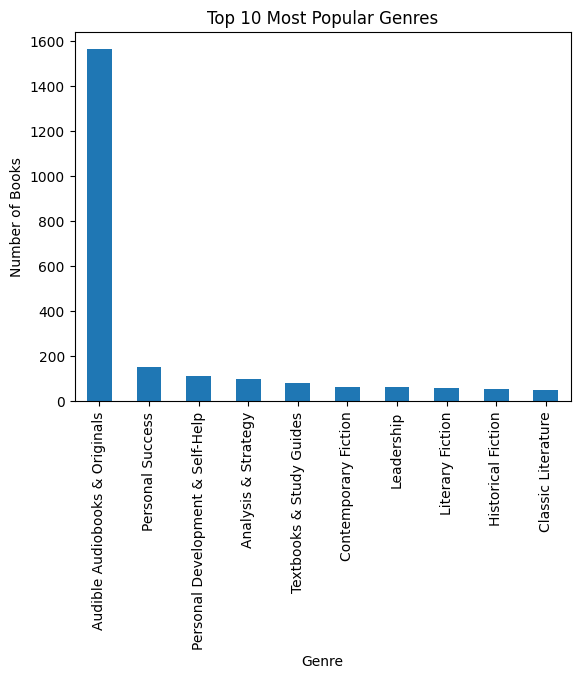

In [26]:
#1 What are the most popular genres in the dataset?
all_genres = df_final['Genres_List'].explode()
all_genres

top_genres = all_genres.value_counts().head(10)

print(top_genres)

top_genres.plot(kind='bar')
plt.title("Top 10 Most Popular Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.xticks(rotation=90)
plt.show()

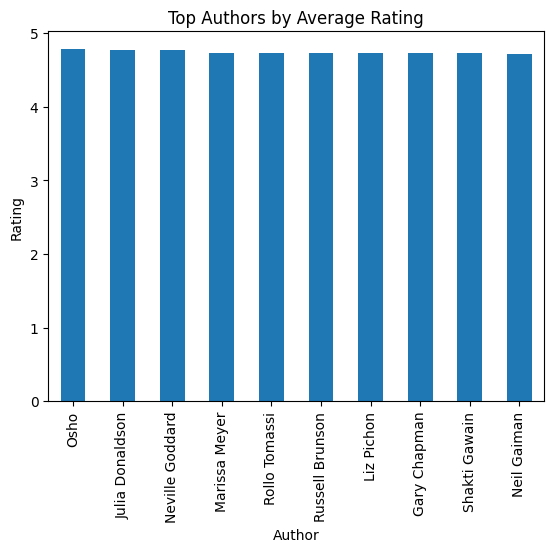

In [27]:
#2 Which authors have the highest-rated books?
author_stats = df_final.groupby('Author').agg({
    'Rating': 'mean',
    'Book Name': 'count'
})
author_stats = author_stats[author_stats['Book Name'] >= 3]
top_authors = author_stats.sort_values(by='Rating', ascending=False).head(10)
top_authors['Rating'].plot(kind='bar')
plt.title("Top Authors by Average Rating")
plt.ylabel("Rating")
plt.xlabel("Author")
plt.xticks(rotation=90)
plt.show()


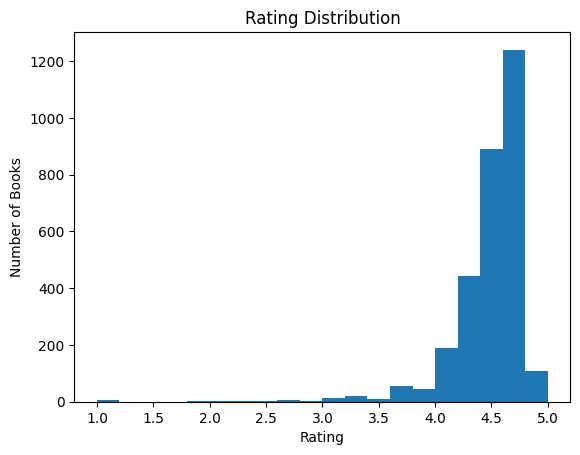

In [28]:
#3 .What is the average rating distribution across books?
plt.hist(df_final['Rating'], bins=20)
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Rating Distribution")
plt.show()

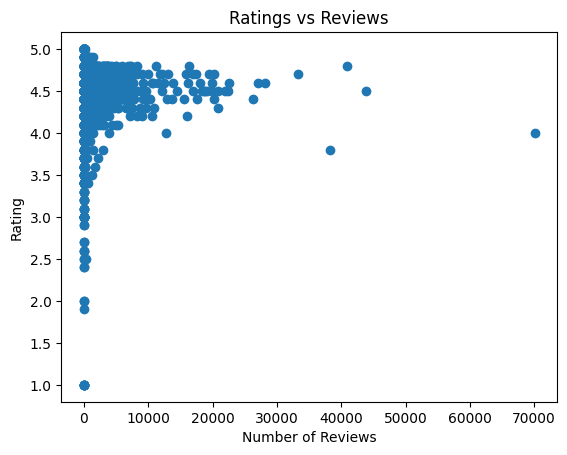

In [29]:
#4 How do ratings vary between books with different review counts
plt.scatter(df_final['Number of Reviews'], df_final['Rating'])
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.title("Ratings vs Reviews")
plt.show()

In [30]:
#5 Which books are frequently clustered together based on descriptions?
df_final['Description'] = df_final['Description'].fillna('')
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df_final['Description'])
kmeans = KMeans(n_clusters=5, random_state=42)
df_final['Cluster'] = kmeans.fit_predict(X)



for cluster_id in sorted(df_final['Cluster'].unique()):
    cluster_books = df_final[df_final['Cluster'] == cluster_id]
    
    print(f"\n📚 CLUSTER {cluster_id} ({len(cluster_books)} books)")
    print("-" * 100)
    

    top_books = cluster_books.head(5)
    
    for idx, row in top_books.iterrows():
        book_info = f"  • {row['Book Name']}"
        if 'Author' in row:
            book_info += f" by {row['Author']}"
        if 'Rating' in row:
            book_info += f" (Rating: {row['Rating']:.2f})"
        print(book_info)


📚 CLUSTER 0 (666 books)
----------------------------------------------------------------------------------------------------
  • Men Are from Mars, Women Are from Venus: The Classic Guide to Understanding the Opposite Sex by John Gray (Rating: 4.50)
  • Hit Refresh by Satya Nadella (Rating: 4.40)
  • A Game of Thrones: Book 1 of A Song of Ice and Fire by George R. R. Martin (Rating: 4.70)
  • The 10X Rule: The Only Difference Between Success and Failure by Grant Cardone (Rating: 4.60)
  • The Hard Thing About Hard Things: Building a Business When There Are No Easy Answers by Ben Horowitz (Rating: 4.60)

📚 CLUSTER 1 (394 books)
----------------------------------------------------------------------------------------------------
  • A Gentleman in Moscow by Amor Towles (Rating: 4.60)
  • Apke Avchetan Man Ki Shakti [The Power of Your Subconscious Mind] by Dr. Joseph Murphy (Rating: 4.50)
  • Trading in the Zone: Master the Market with Confidence, Discipline, and a Winning Attitude by Mar

0       [Audible Audiobooks & Originals, Personal Succ...
1       [Audible Audiobooks & Originals, Meditation, S...
2       [Audible Audiobooks & Originals, Personal Succ...
3       [Audible Audiobooks & Originals, Psychology, S...
4       [Audible Audiobooks & Originals, Literary Essa...
                              ...                        
3026                                                   []
3027                                                   []
3028                                                   []
3029                                                   []
3030    [Audible Audiobooks & Originals, Low Carb Diet...
Name: Genres_List, Length: 3030, dtype: object


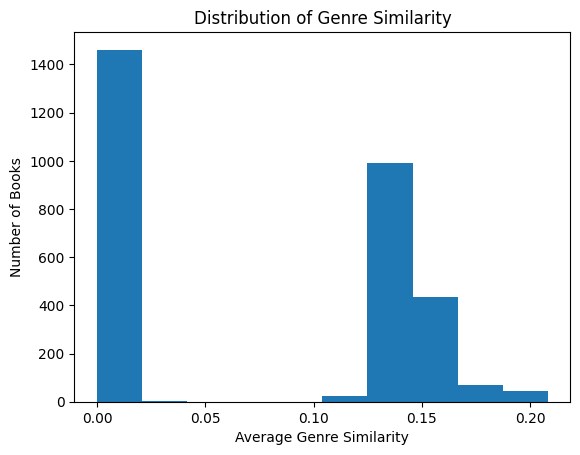

In [87]:
#How does genre similarity affect book recommendations?

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df_final['Genres_List'])
print(df_final['Genres_List'])
df_final['Genre_Count'] = df_final['Genres_List'].apply(len)
genresimilarity_matrix = cosine_similarity(genre_matrix)
avg_similarity = genresimilarity_matrix.mean(axis=1)

plt.figure()
plt.hist(avg_similarity, bins=10)
plt.xlabel("Average Genre Similarity")
plt.ylabel("Number of Books")
plt.title("Distribution of Genre Similarity")
plt.show()



In [90]:


# Convert genre list to a single string per book
# e.g. ["Mystery", "Thriller"] → "Mystery Thriller"
df_final['genres_string'] = df_final['Genres_List'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else ''
)

# Fit TF-IDF on genre strings
# Use underscore for multi-word genres so "Paranormal Romance" → "Paranormal_Romance"
df_final['genres_string'] = df_final['Genres_List'].apply(
    lambda x: ' '.join([g.replace(' ', '_') for g in x]) if isinstance(x, list) else ''
)

tfidf_genre  = TfidfVectorizer(
    max_features=5000,  # Keep top 5000 most important words
    ngram_range=(1, 2),  # Use both single words and pairs of words
    min_df=2,  # Word must appear in at least 2 documents
    max_df=0.8  # Ignore words that appear in more than 80% of documents
)
tfidf_genre_matrix = tfidf_genre.fit_transform(df_final['genres_string'])

# Build new similarity matrix
cosine_sim_genre_tfidf = cosine_similarity(tfidf_genre_matrix)

print(f"Shape: {cosine_sim_genre_tfidf.shape}")
print(f"Sample scores: {cosine_sim_genre_tfidf[0][:5]}")


Shape: (3030, 3030)
Sample scores: [1.         0.11240949 0.27317807 0.35522171 0.03949107]


In [ ]:
#Effect of author popularity on ratin
author_stats = df_final.groupby('Author').agg({
    'Rating': 'mean',
    'Number of Reviews': 'sum'
}).sort_values(by='Number of Reviews', ascending=False)

print(author_stats.head(10))

                   Rating  Number of Reviews
Author                                      
E. L. James      4.150000            80983.0
Paula Hawkins    4.000000            70077.0
Jeff Kinney      4.606667            65464.0
Rick Riordan     4.695455            62252.0
Suzanne Collins  4.625000            61075.0
John Green       4.433333            54424.0
Dan Brown        4.400000            47164.0
Kristin Hannah   4.800000            40839.0
Jojo Moyes       4.633333            38504.0
J.K. Rowling     4.657143            36986.0


In [70]:
if 'Rating' in df_final.columns:
    def categorize_rating(rating):
        """
        Categorize rating into quality tiers:
        - Excellent: 4.5 and above
        - Good: 4.0 to 4.5
        - Average: 3.5 to 4.0
        - Below Average: below 3.5
        """
        if pd.isna(rating):
            return 'Unknown'
        elif rating >= 4.5:
            return 'Excellent'
        elif rating >= 4.0:
            return 'Good'
        elif rating >= 3.5:
            return 'Average'
        else:
            return 'Below Average'
    
df_final['rating_category'] = df_final['Rating'].apply(categorize_rating)

df_final

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre,Genre,Genres_List,Cluster,Genre_Count,rating_category
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top...",#2 in Society & Culture (Books),"[Audible Audiobooks & Originals, Personal Succ...",2,4,Excellent
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top...",#2 in Personal Success,"[Audible Audiobooks & Originals, Meditation, S...",4,4,Excellent
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top...",#16 in Personal Development & Self-Help,"[Audible Audiobooks & Originals, Personal Succ...",2,3,Good
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top...",#4 in Personal Success,"[Audible Audiobooks & Originals, Psychology, S...",4,4,Excellent
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top...",#1 in Spiritualism,"[Audible Audiobooks & Originals, Literary Essa...",2,4,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3026,The Death of WCW,R.D. Reynolds,4.6,271.0,836.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[],0,0,Excellent
3027,The Prophet & The Wanderer,Khalil Gibran,4.1,6.0,539.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[],0,0,Good
3028,Make Today Count: The Secret of Your Success I...,John C. Maxwell,4.7,301.0,500.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[],0,0,Excellent
3029,"Kill the Company: End the Status Quo, Start an...",Lisa Bodell,4.2,26.0,586.0,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1,-1,[],1,0,Good


##  NLP Processing

**Purpose:** Extract text features from book descriptions and titles for content-based recommendations.

In [32]:
def preprocess_text(text):
    if pd.isna(text) or text == '':
        return ''
    
    text = str(text).lower()
    
    text = re.sub(r'[^a-z\s]', '', text)
    
    text = ' '.join(text.split())
    
    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatization (reduce words to base form)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

print("✅ Text preprocessing function created!")

# Test the function
sample_text = "The Running Man is an amazing story about running through the city!"
processed_sample = preprocess_text(sample_text)
print(f"\nOriginal: {sample_text}")
print(f"Processed: {processed_sample}")

✅ Text preprocessing function created!

Original: The Running Man is an amazing story about running through the city!
Processed: running man amazing story running city


In [33]:
df_final.columns

Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price',
       'Description', 'Listening Time', 'Ranks and Genre', 'Genre',
       'Genres_List', 'Cluster', 'Genre_Count'],
      dtype='object')

In [60]:


if 'Description' in df_final.columns:
    print("Processing descriptions...")
    df_final['description_clean'] = df_final['Description'].apply(preprocess_text)
    print("✅ Descriptions processed!")

if 'Book Name' in df_final.columns:
    print("Processing book names...")
    df_final['name_clean'] = df_final['Book Name'].apply(preprocess_text)
    print("✅ Book names processed!")

# Create combined text feature (description + name) for comprehensive matching
# This allows recommendations based on both title and description
df_final['combined_text'] = ''

if 'name_clean' in df_final.columns:
    df_final['combined_text'] += df_final['name_clean'] + ' '

if 'description_clean' in df_final.columns:
    df_final['combined_text'] += df_final['description_clean']

df_final['combined_text'] = df_final['combined_text'].str.strip()
df_final['genre_text'] = df_final['Genres_List'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
books_with_text = df_final['combined_text'].str.len() > 0

df_final['combined_textwith_genre'] =df_final['combined_text'] + df_final['genre_text']
print(f"\nBooks with text content: {books_with_text.sum()}")
print(f"Books without text: {(~books_with_text).sum()}")

Processing descriptions...
✅ Descriptions processed!
Processing book names...
✅ Book names processed!

Books with text content: 3030
Books without text: 0


In [ ]:
df_final


,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre,Genre,Genres_List,Cluster,Genre_Count,description_clean,name_clean,combined_text,combined_textwith_genre,genre_text
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top...",#2 in Society & Culture (Books),"[Audible Audiobooks & Originals, Personal Succ...",1,4,past three year jay shetty become one world po...,think like monk secret harness power positivit...,think like monk secret harness power positivit...,think like monk secret harness power positivit...,Audible Audiobooks & Originals Personal Succes...
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top...",#2 in Personal Success,"[Audible Audiobooks & Originals, Meditation, S...",1,4,brought penguin,ikigai japanese secret long happy life,ikigai japanese secret long happy life brought...,ikigai japanese secret long happy life brought...,Audible Audiobooks & Originals Meditation Self...
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top...",#16 in Personal Development & Self-Help,"[Audible Audiobooks & Originals, Personal Succ...",1,3,generationdefining selfhelp guide superstar bl...,subtle art giving fck counterintuitive approac...,subtle art giving fck counterintuitive approac...,subtle art giving fck counterintuitive approac...,Audible Audiobooks & Originals Personal Succes...
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top...",#4 in Personal Success,"[Audible Audiobooks & Originals, Psychology, S...",1,4,brought penguin,atomic habit easy proven way build good habit ...,atomic habit easy proven way build good habit ...,atomic habit easy proven way build good habit ...,Audible Audiobooks & Originals Psychology Stre...
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top...",#1 in Spiritualism,"[Audible Audiobooks & Originals, Literary Essa...",1,4,stop going life start growing life,life amazing secret find balance purpose life,life amazing secret find balance purpose life ...,life amazing secret find balance purpose life ...,Audible Audiobooks & Originals Literary Essays...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3026,The Death of WCW,R.D. Reynolds,4.6,271.0,836.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[],0,0,sorry need make sure youre robot best result p...,death wcw,death wcw sorry need make sure youre robot bes...,death wcw sorry need make sure youre robot bes...,
3027,The Prophet & The Wanderer,Khalil Gibran,4.1,6.0,539.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[],0,0,sorry need make sure youre robot best result p...,prophet wanderer,prophet wanderer sorry need make sure youre ro...,prophet wanderer sorry need make sure youre ro...,
3028,Make Today Count: The Secret of Your Success I...,John C. Maxwell,4.7,301.0,500.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[],0,0,sorry need make sure youre robot best result p...,make today count secret success determined dai...,make today count secret success determined dai...,make today count secret success determined dai...,
3029,"Kill the Company: End the Status Quo, Start an...",Lisa Bodell,4.2,26.0,586.0,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1,-1,[],2,0,oops rush hour traffic piling page please try ...,kill company end st

In [62]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Keep top 5000 most important words
    ngram_range=(1, 2),  # Use both single words and pairs of words
    min_df=2,  # Word must appear in at least 2 documents
    max_df=0.8  # Ignore words that appear in more than 80% of documents
)

# Fit and transform the combined text
# This creates a matrix where each row is a book and each column is a word
print("Creating TF-IDF vectors...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df_final['combined_text'])

tfidf_matrixwith_genere = tfidf_vectorizer.fit_transform(df_final['combined_textwith_genre'])

print(f"✓ TF-IDF matrix created:")
print(f"  Shape: {tfidf_matrix.shape}")
print(f"  ({tfidf_matrix.shape[0]} books × {tfidf_matrix.shape[1]} features)")
print(f"  Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")


print(f"✓ TF-IDF matrix created:")
print(f"  Shape: {tfidf_matrixwith_genere.shape}")
print(f"  ({tfidf_matrixwith_genere.shape[0]} books × {tfidf_matrixwith_genere.shape[1]} features)")
print(f"  Sparsity: {(1 - tfidf_matrixwith_genere.nnz / (tfidf_matrixwith_genere.shape[0] * tfidf_matrixwith_genere.shape[1])) * 100:.2f}%")

Creating TF-IDF vectors...
✓ TF-IDF matrix created:
  Shape: (3030, 5000)
  (3030 books × 5000 features)
  Sparsity: 99.44%
✓ TF-IDF matrix created:
  Shape: (3030, 5000)
  (3030 books × 5000 features)
  Sparsity: 99.33%


In [ ]:
print("Calculating cosine similarity matrix...")
similarity_matrix = cosine_similarity(tfidf_matrix) 

print(f"✓ Similarity matrix created: {similarity_matrix.shape}")


print("Calculating cosine similarity matrix with gemre...")
similarity_matrix_genre = cosine_similarity(tfidf_matrixwith_genere)

print(f"✓ Similarity matrix created: {similarity_matrix_genre.shape}")

Calculating cosine similarity matrix...
✓ Similarity matrix created: (3030, 3030)
Calculating cosine similarity matrix with gemre...
✓ Similarity matrix created: (3030, 3030)


In [71]:
# Try different numbers of clusters
inertias = []  # Sum of squared distances to cluster centers
silhouette_scores = []  # Measure of cluster quality
k_range = range(2, 11) 

pca = PCA(n_components=100, random_state=42)  # Reduce to 100 dimensions
tfidf_reduced = pca.fit_transform(tfidf_matrix.toarray())

print(f"Reduced TF-IDF matrix to {tfidf_reduced.shape[1]} components")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

for k in k_range:
    # Train K-means with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_reduced)
    
    # Store inertia (lower is better, but we look for elbow)
    inertias.append(kmeans.inertia_)
    
    # Calculate silhouette score (higher is better, range -1 to 1)
    sil_score = silhouette_score(tfidf_reduced, kmeans.labels_)
    silhouette_scores.append(sil_score)
    
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.3f}")

Reduced TF-IDF matrix to 100 components
Explained variance: 37.47%
K=2: Inertia=771.31, Silhouette=0.322
K=3: Inertia=539.45, Silhouette=0.414
K=4: Inertia=493.99, Silhouette=0.432
K=5: Inertia=469.31, Silhouette=0.399
K=6: Inertia=454.33, Silhouette=0.353
K=7: Inertia=445.29, Silhouette=0.345
K=8: Inertia=441.43, Silhouette=0.161
K=9: Inertia=433.86, Silhouette=0.347
K=10: Inertia=428.22, Silhouette=0.263


In [80]:
# Try different numbers of clusters
inertias_genre = []  # Sum of squared distances to cluster centers
silhouette_scores_genre = []  # Measure of cluster quality
k_range_genre = range(2, 11) 

pca_genre = PCA(n_components=100, random_state=42) 
tfidf_reduced_genre = pca.fit_transform(tfidf_matrixwith_genere.toarray())

print(f"Reduced TF-IDF matrix to {tfidf_reduced_genre.shape[1]} components")
# print(f"Explained variance: {pca_genre.explained_variance_ratio_.sum():.2%}")

for k in k_range_genre:
    # Train K-means with k clusters
    kmeans_genre = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_genre.fit(tfidf_reduced_genre)
    
    # Store inertia (lower is better, but we look for elbow)
    inertias_genre.append(kmeans_genre.inertia_)
    
    # Calculate silhouette score (higher is better, range -1 to 1)
    sil_score_genre = silhouette_score(tfidf_matrixwith_genere, kmeans_genre.labels_)
    silhouette_scores.append(sil_score_genre)
    
    print(f"K={k}: Inertia={kmeans_genre.inertia_:.2f}, Silhouette={sil_score_genre:.3f}")

Reduced TF-IDF matrix to 100 components
K=2: Inertia=836.76, Silhouette=0.096
K=3: Inertia=596.18, Silhouette=0.149
K=4: Inertia=561.65, Silhouette=0.153
K=5: Inertia=543.91, Silhouette=0.155
K=6: Inertia=529.07, Silhouette=0.155
K=7: Inertia=517.87, Silhouette=0.157
K=8: Inertia=505.25, Silhouette=0.158
K=9: Inertia=500.09, Silhouette=0.158
K=10: Inertia=494.33, Silhouette=0.089


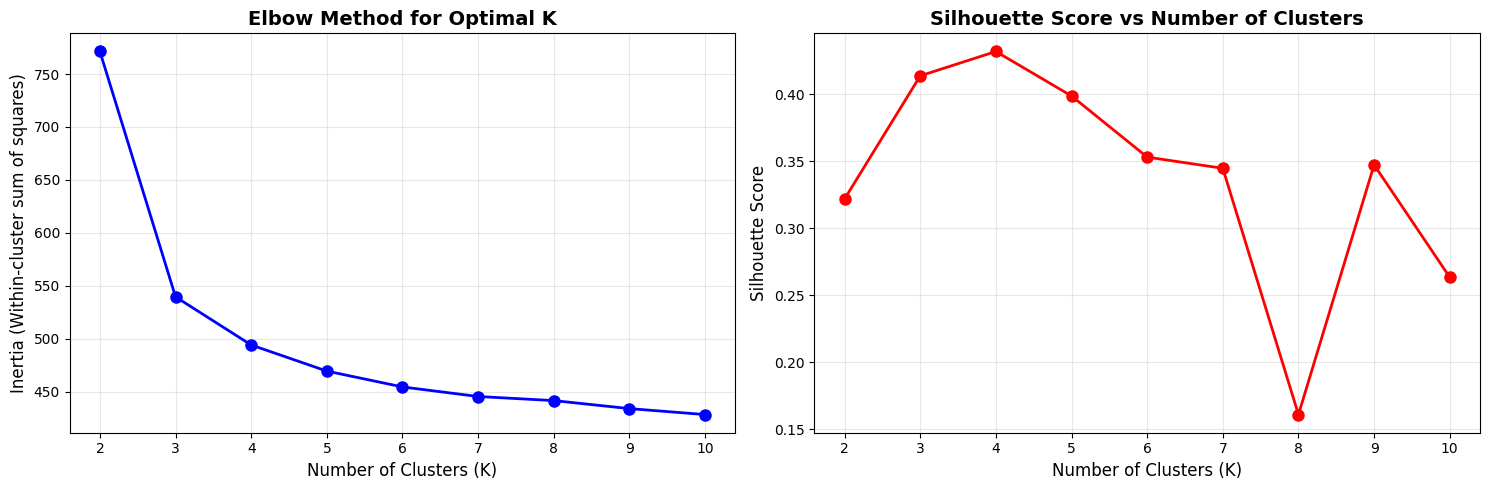


✅ Optimal number of clusters: 4
Best silhouette score: 0.432


In [46]:
# Visualize elbow plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow plot (inertia)
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette score plot
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal K based on silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\n✅ Optimal number of clusters: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.3f}")

Performing K-Means clustering with 4 clusters...
✓ Clustering completed
Silhouette Score: 0.4317

Cluster Distribution:
  Cluster 0:  666 books ( 19.9%)
  Cluster 1: 1916 books ( 57.2%)
  Cluster 2:  394 books ( 11.8%)
  Cluster 3:   54 books (  1.6%)


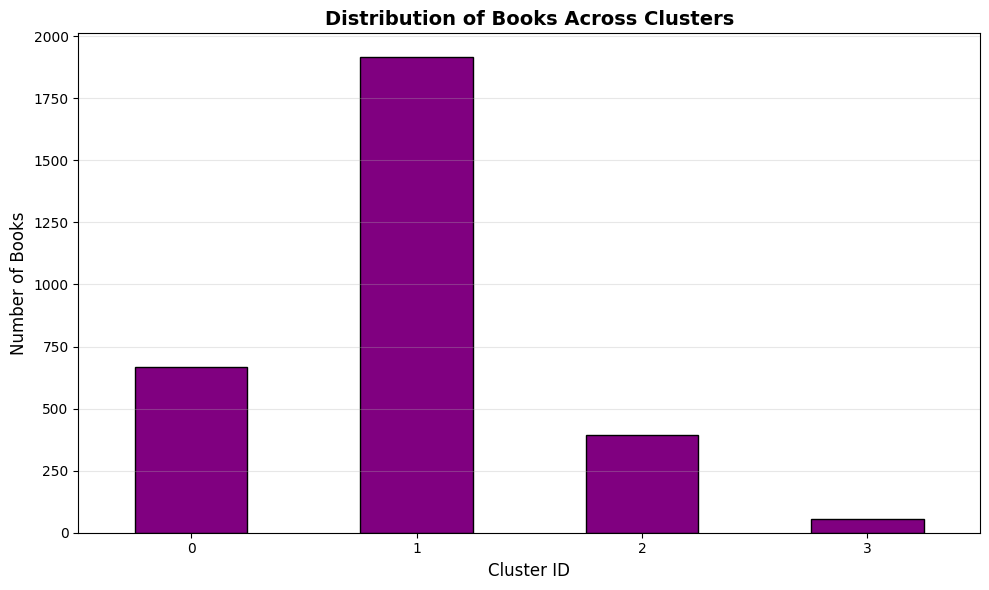

In [73]:
# Perform K-Means clustering
n_clusters = 4
print(f"Performing K-Means clustering with {n_clusters} clusters...")

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, max_iter=300)
df_final['Cluster'] = kmeans.fit_predict(tfidf_reduced)

print(f"✓ Clustering completed")
sil_score = silhouette_score(tfidf_reduced, df_final['Cluster'], sample_size=1500)


print(f"Silhouette Score: {sil_score:.4f}")
# Cluster distribution
cluster_counts = df_final['Cluster'].value_counts().sort_index()
print(f"\nCluster Distribution:")
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count:4d} books ({count/len(df)*100:5.1f}%)")

plt.figure(figsize=(10, 6))
df_final['Cluster'].value_counts().sort_index().plot(kind='bar', color='purple', edgecolor='black')
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)
plt.title('Distribution of Books Across Clusters', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig('../visualizations/cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
#5 Which books are frequently clustered together based on descriptions?



for cluster_id in sorted(df_final['Cluster'].unique()):
    cluster_books = df_final[df_final['Cluster'] == cluster_id]
    
    print(f"\n📚 CLUSTER {cluster_id} ({len(cluster_books)} books)")
    print("-" * 100)
    

    top_books = cluster_books.head(5)
    
    for idx, row in top_books.iterrows():
        book_info = f"  • {row['Book Name']}"
        if 'Author' in row:
            book_info += f" by {row['Author']}"
        if 'Rating' in row:
            book_info += f" (Rating: {row['Rating']:.2f})"
        print(book_info)


📚 CLUSTER 0 (666 books)
----------------------------------------------------------------------------------------------------
  • Men Are from Mars, Women Are from Venus: The Classic Guide to Understanding the Opposite Sex by John Gray (Rating: 4.50)
  • Hit Refresh by Satya Nadella (Rating: 4.40)
  • A Game of Thrones: Book 1 of A Song of Ice and Fire by George R. R. Martin (Rating: 4.70)
  • The 10X Rule: The Only Difference Between Success and Failure by Grant Cardone (Rating: 4.60)
  • The Hard Thing About Hard Things: Building a Business When There Are No Easy Answers by Ben Horowitz (Rating: 4.60)

📚 CLUSTER 1 (1916 books)
----------------------------------------------------------------------------------------------------
  • Think Like a Monk: The Secret of How to Harness the Power of Positivity and Be Happy Now by Jay Shetty (Rating: 4.90)
  • Ikigai: The Japanese Secret to a Long and Happy Life by Héctor García (Rating: 4.60)
  • The Subtle Art of Not Giving a F*ck: A Counteri

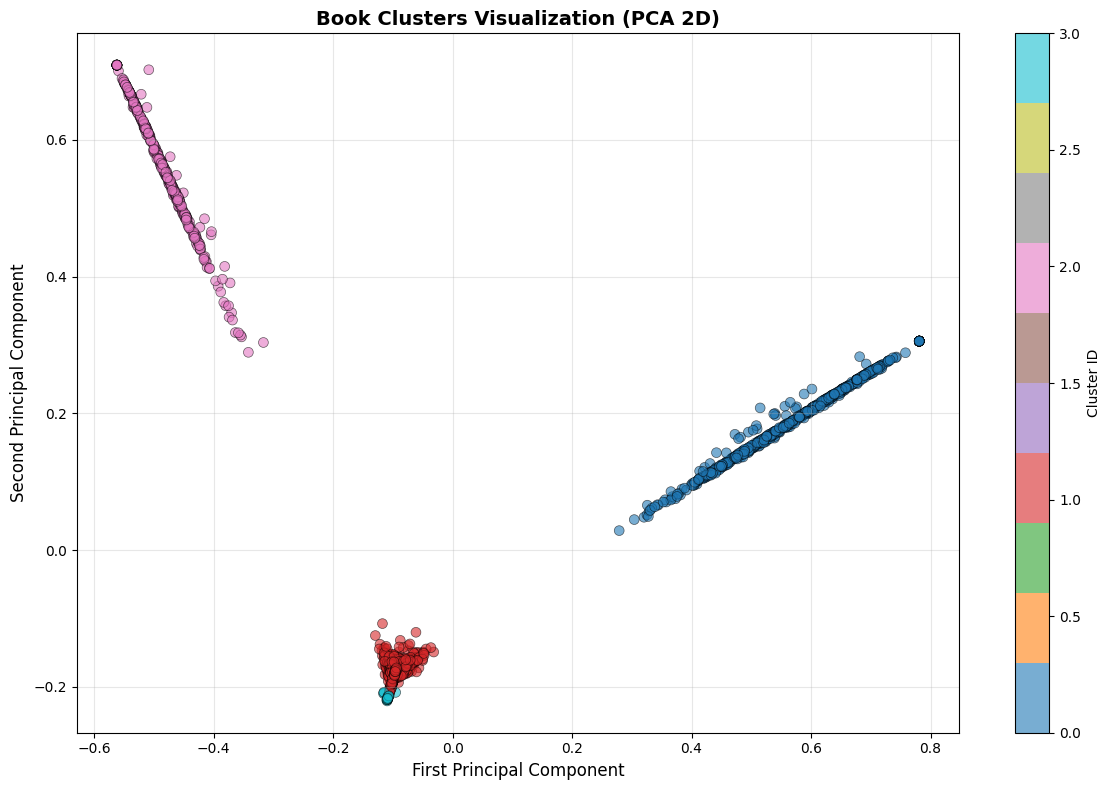

Explained variance by 2 components: 51.41%


In [75]:


pca_2d = PCA(n_components=2, random_state=42)
tfidf_2d = pca_2d.fit_transform(tfidf_reduced)

# Create scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    tfidf_2d[:, 0],
    tfidf_2d[:, 1],
    c=df_final['Cluster'],
    cmap='tab10',
    alpha=0.6,
    s=50,
    edgecolors='black',
    linewidth=0.5
)
plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('Book Clusters Visualization (PCA 2D)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('../visualizations/clusters_2d_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Explained variance by 2 components: {pca_2d.explained_variance_ratio_.sum():.2%}")

In [78]:
print(similarity_matrix)

[[2.         0.56816336 0.59464446 ... 0.01560022 0.         0.25      ]
 [0.56816336 2.         0.59754132 ... 0.04656462 0.         0.25      ]
 [0.59464446 0.59754132 2.         ... 0.         0.02405203 0.29923722]
 ...
 [0.01560022 0.04656462 0.         ... 1.         0.0075894  0.        ]
 [0.         0.         0.02405203 ... 0.0075894  1.         0.        ]
 [0.25       0.25       0.29923722 ... 0.         0.         2.        ]]


In [92]:
# Create models directory if it doesn't exist
import os
os.makedirs('../models', exist_ok=True)

print("Saving all models and data...\n")

# 1. Save processed dataframe
# This contains all cleaned data and engineered features
df_final.to_pickle('../models/books_data.pkl')
print("✅ Saved: books_data.pkl")

# 2. Save TF-IDF vectorizer
# Needed to transform new text inputs in the same way
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("✅ Saved: tfidf_vectorizer.pkl")

# 3. Save TF-IDF matrix
# Pre-computed text features for all books
with open('../models/tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_reduced, f)
print("✅ Saved: tfidf_matrix.pkl")

# 4. Save cosine similarity matrix
# Pre-computed similarities between all books (faster recommendations)
with open('../models/cosine_similarity_matrix.pkl', 'wb') as f:
    pickle.dump(similarity_matrix, f)
print("✅ Saved: cosine_similarity_matrix.pkl")

with open('../models/cosine_genere_similarity_matrix.pkl', 'wb') as f:
    pickle.dump(genresimilarity_matrix, f)
print("✅ Saved: cosine_genere_similarity_matrix.pkl")


# Save — overwrite or save as a new file
with open('../models/cosine_similarity_genre.pkl', 'wb') as f:
    pickle.dump(cosine_sim_genre_tfidf, f)
print("✅ Saved: cosine_similarity_genre.pkl")


# 5. Save K-means model
# Clustering model for cluster-based recommendations
with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("✅ Saved: kmeans_model.pkl")




print("\n" + "="*100)
print("🎉 ALL MODELS AND DATA SAVED SUCCESSFULLY!")
print("="*100)
print("\nSaved files:")
print("  1. books_data.pkl - Processed dataframe with all features")
print("  2. tfidf_vectorizer.pkl - TF-IDF vectorizer model")
print("  3. tfidf_matrix.pkl - Pre-computed TF-IDF features")
print("  4. cosine_similarity_matrix.pkl - Pre-computed book similarities")
print("  5. kmeans_model.pkl - Clustering model")
print("\nThese files will be used by the Streamlit app for real-time recommendations.")

Saving all models and data...

✅ Saved: books_data.pkl
✅ Saved: tfidf_vectorizer.pkl
✅ Saved: tfidf_matrix.pkl
✅ Saved: cosine_similarity_matrix.pkl
✅ Saved: cosine_genere_similarity_matrix.pkl
✅ Saved: cosine_similarity_genre.pkl
✅ Saved: kmeans_model.pkl

🎉 ALL MODELS AND DATA SAVED SUCCESSFULLY!

Saved files:
  1. books_data.pkl - Processed dataframe with all features
  2. tfidf_vectorizer.pkl - TF-IDF vectorizer model
  3. tfidf_matrix.pkl - Pre-computed TF-IDF features
  4. cosine_similarity_matrix.pkl - Pre-computed book similarities
  5. kmeans_model.pkl - Clustering model

These files will be used by the Streamlit app for real-time recommendations.


In [77]:
df_final

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre,Genre,Genres_List,Cluster,Genre_Count,description_clean,name_clean,combined_text,combined_textwith_genre,genre_text
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top...",#2 in Society & Culture (Books),"[Audible Audiobooks & Originals, Personal Succ...",1,4,past three year jay shetty become one world po...,think like monk secret harness power positivit...,think like monk secret harness power positivit...,think like monk secret harness power positivit...,Audible Audiobooks & Originals Personal Succes...
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top...",#2 in Personal Success,"[Audible Audiobooks & Originals, Meditation, S...",1,4,brought penguin,ikigai japanese secret long happy life,ikigai japanese secret long happy life brought...,ikigai japanese secret long happy life brought...,Audible Audiobooks & Originals Meditation Self...
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top...",#16 in Personal Development & Self-Help,"[Audible Audiobooks & Originals, Personal Succ...",1,3,generationdefining selfhelp guide superstar bl...,subtle art giving fck counterintuitive approac...,subtle art giving fck counterintuitive approac...,subtle art giving fck counterintuitive approac...,Audible Audiobooks & Originals Personal Succes...
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top...",#4 in Personal Success,"[Audible Audiobooks & Originals, Psychology, S...",1,4,brought penguin,atomic habit easy proven way build good habit ...,atomic habit easy proven way build good habit ...,atomic habit easy proven way build good habit ...,Audible Audiobooks & Originals Psychology Stre...
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top...",#1 in Spiritualism,"[Audible Audiobooks & Originals, Literary Essa...",1,4,stop going life start growing life,life amazing secret find balance purpose life,life amazing secret find balance purpose life ...,life amazing secret find balance purpose life ...,Audible Audiobooks & Originals Literary Essays...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3026,The Death of WCW,R.D. Reynolds,4.6,271.0,836.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[],0,0,sorry need make sure youre robot best result p...,death wcw,death wcw sorry need make sure youre robot bes...,death wcw sorry need make sure youre robot bes...,
3027,The Prophet & The Wanderer,Khalil Gibran,4.1,6.0,539.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[],0,0,sorry need make sure youre robot best result p...,prophet wanderer,prophet wanderer sorry need make sure youre ro...,prophet wanderer sorry need make sure youre ro...,
3028,Make Today Count: The Secret of Your Success I...,John C. Maxwell,4.7,301.0,500.0,"Sorry, we just need to make sure you're not a ...",-1,-1,-1,[],0,0,sorry need make sure youre robot best result p...,make today count secret success determined dai...,make today count secret success determined dai...,make today count secret success determined dai...,
3029,"Kill the Company: End the Status Quo, Start an...",Lisa Bodell,4.2,26.0,586.0,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1,-1,[],2,0,oops rush hour traffic piling page please try ...,kill company end st